# The Gator Oscillator — a quantitative teardown 🔬
### A pooled wake-event study across 1/5/10/20-day horizons · a magnitude (trend-capture) test · a real SPY timer vs buy-and-hold and vs the plain Alligator · a block-permutation placebo that unmasks a Sharpe artifact · a synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Catches_trend_starts%3F: Busted](https://img.shields.io/badge/Catches_trend_starts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Gator Oscillator is not an independent signal — it is the rate-of-change of sibling [421-williams-alligator](../421-williams-alligator/)'s own three SMMAs, plotted as a green/red histogram. The job here is a narrow, honest question: does watching that histogram's color change — specifically the "wake" transition — add a real, tradable timing edge over the fan it's built from?

> ⚠️ **Data note.** 30-name basket (SPY + 29 liquid US large-caps), yfinance daily OHLCV, `auto_adjust=True`, 2000-01-03 → 2026-06-30. **Survivors basket** — named on the Signal axis. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `7b64d4cd54dd` basket / `eed0b5d1f41e` SPY).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gator_oscillator import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_panel()
    SPY = PANEL["SPY"]
else:
    PANEL = SPY = None
print("real cache present:", HAVE_REAL, "| basket names:",
      (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-06-30', 'n_names': 30, 'min_sleep': 3, 'event': {1: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': 0.013, 'base': 0.03, 'win': 52.1, 't_welch': -0.17, 't_hac': 0.13, 'p': 0.4682, 'net': -0.088, 'mean_abs': 1.001, 'base_abs': 1.043, 't_abs': -0.83, 'p_abs': 0.7434}, 5: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': -0.009, 'base': 0.233, 'win': 49.5, 't_welch': -1.09, 't_hac': -0.04, 'p': 0.51, 'net': -0.114, 'mean_abs': 2.497, 'base_abs': 2.645, 't_abs': -1.2, 'p_abs': 0.8424}, 10: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': -0.119, 'base': 0.479, 'win': 46.9, 't_welch': -1.88, 't_hac': -0.4, 'p': 0.6342, 'net': -0.229, 'mean_abs': 3.364, 'base_abs': 3.785, 't_abs': -2.41, 'p_abs': 0.9772}, 20: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': 0.604, 'base': 0.976, 'win': 51.0, 't_welch': -0.73, 't_hac': 1.35, 'p': 0.1356, 'net': 0.484, 'mean_abs': 5.169, 'base_abs': 5.431, 't_abs': -0.99, 'p_abs': 0.8092}}, 'hold_days': 10, 'bh': {'cagr': 8.28, 'sharpe': 0.412, 'vol': 19.32, 'dd': -55.19, 't': 2.42}, 'wake': {'cagr': 4.26, 'sharpe': 2.548, 'vol': 1.64, 'dd': -5.67, 't': 15.22}, 'fan': {'cagr': 2.26, 'sharpe': 0.126, 'vol': 17.69, 'dd': -37.48, 't': 0.75}, 't_wake_vs_bh': -1.16, 't_wake_vs_fan': 0.65, 'placebo_p': 0.512, 'placebo_obs': 2.136, 'n_wakes_spy': 13, 'in_pos_frac': 0.9, 'cost10_cagr': 4.23, 'cost10_sharpe': 2.531, 'syn_null_mean': 0.41, 'syn_null_sd': 0.78, 'syn_null_fire': 0, 'syn_null_seeds': 10, 'syn_planted_t': 3.2, 'syn_planted_welch': 2.54, 'syn_planted_mean': 7.02, 'syn_planted_base': 0.67, 'syn_planted_win': 78.6, 'syn_planted_n': 14, 'fp_basket': '7b64d4cd54dd', 'fp_spy': 'eed0b5d1f41e'}


real cache present: True | basket names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | signed 10-day wake return Welch **t = -1.88**, HAC **t = -0.40**; no horizon clears \|t\| ≥ 2; magnitude test at 10d: Welch **t = -2.41** (wrong sign) |
| **Tradability** | `MIRAGE` | Sharpe-diff *t* (wake vs BH) = **-1.16**; vs the plain Alligator fan *t* = **0.65**; block-permutation placebo **p = 0.512** |
| **Catches trend starts?** | `BUSTED` | machinery detects a planted trend at *t* = **3.20**; real tape shows nothing directional |

> 💡 In plain words: the Gator's histogram is a decoration on top of the Alligator's own lines — geometrically real, statistically empty.

## 1 · The claim, steelmanned

Let $J_t, Te_t, L_t$ be the Alligator's Jaw/Teeth/Lips (SMMA(13/8/5) of median price, forward-shifted 8/5/3 bars — identical to sibling 421). The Gator histograms are $U_t = |J_t - Te_t|$ (upper) and $Lo_t = |Te_t - L_t|$ (lower), each colored GREEN if taller than $t-1$, RED otherwise. A **wake** at $t$ requires both $U$ and $Lo$ green at $t$ and both red for $\geq 3$ consecutive prior bars ($t-1$ back through $t-3$) — a genuine sleep, not a single-day flicker (which fires on ~24% of days and is not the claim). The claims:

- **H₁ (direction).** $E[\text{signed fwd ret} \mid \text{wake}] \gg 0$ at some horizon, where the sign comes from the concurrent Alligator fan.
- **H₂ (magnitude / trend-capture).** $E[|\text{fwd ret}| \mid \text{wake}] > E[|\text{fwd ret}|]$ unconditionally — a wake flags *action ahead*, regardless of direction.
- **H₃ (capture).** A real timer built on the wake signal beats buy-and-hold **and** beats simply being in the Alligator fan continuously (421's rule) net of costs.

We find **H₁ not supported** at any of the four horizons tested, **H₂ not supported** (and reversed in sign at 10 days), **H₃ not supported** once the Sharpe-difference is tested properly rather than eyeballed.

## 2 · So what? — inference design

Wake events are pooled across a **30-name basket** so the event study has real power (346 events, 192 with a directional fan). Because events on the same name can cluster in time, the primary statistic is a **HAC (Newey-West) one-sample *t*** on the signed forward return; a **Welch *t*** against the unconditional base rate (every bar of every name, same window) checks the split isn't just "stocks tend to rise"; a **5,000-draw label-shuffle placebo** (random bars, fair-coin sign) checks the observed mean isn't a lucky draw of the same size. The magnitude test uses the same machinery on $|\text{fwd ret}|$. The timer's Sharpe race uses a **Sharpe-difference HAC *t*** (Jobson-Korkie style) and a **2,000-draw circular-block-permutation placebo** that reshuffles the *timing* of the same sparse exposure pattern — the only honest way to ask "could this Sharpe gap be luck."

## 3 · How we'd know — the protocol

- **Basket.** 30 names 2000-01-03 → 2026-06-30, survivors panel (named on Signal).
- **Wake definition.** Both Gator histograms green after ≥ 3 consecutive both-red bars — fixed once, reused in the event study, the timer, and the synthetic control.
- **Headline.** HAC *t* + Welch *t* + 5,000-draw label-shuffle placebo, at 1/5/10/20-day horizons, signed by the concurrent Alligator fan.
- **Magnitude.** Same machinery on |forward return|, unsigned.
- **Execution.** One documented lag: wake/fan known at close $t$; event study enters open $t+1$; timer signal shifted once, held 10 sessions.
- **Timer.** SPY only, 5/10 bps one-way costs, 50 bps/yr borrow on shorts, flat 4%/yr cash-leg proxy while flat (matches sibling 421's convention) — raced against buy-and-hold **and** the plain "always in the fan" rule.
- **Control.** Synthetic trend-persistence panels (20 series each, the synthetic analogue of the real basket); the null must not fire across 10 independent seeds.

## 4 · The teardown

### 4a · The headline event study — signed forward return by horizon

HAC *t*, Welch *t* vs the unconditional base rate, and the label-shuffle placebo, at each horizon.

 horizon  n_wake  n_dir  mean_signed  base_mean     t_hac   t_welch  p_placebo
       1     346    192     0.000133   0.000296  0.130358 -0.169404      0.477
       5     346    192    -0.000092   0.002328 -0.041101 -1.088423      0.517
      10     346    192    -0.001190   0.004788 -0.396293 -1.881868      0.642
      20     346    192     0.006043   0.009761  1.348654 -0.731608      0.133


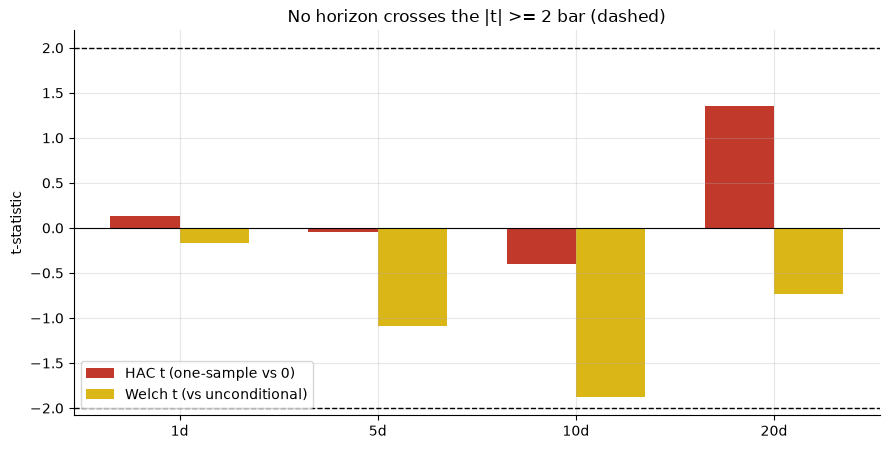

In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL, horizons=st.HORIZONS, n_draws=1000)
    print(res[['horizon','n_wake','n_dir','mean_signed','base_mean','t_hac','t_welch','p_placebo']]
          .to_string(index=False))
    hs = list(res['horizon']); t_hacs = list(res['t_hac']); t_welchs = list(res['t_welch'])
else:
    hs = sorted(R['event'])
    t_hacs = [R['event'][h]['t_hac'] for h in hs]
    t_welchs = [R['event'][h]['t_welch'] for h in hs]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
x = np.arange(len(hs)); w = 0.35
ax.bar(x - w/2, t_hacs, width=w, color=RED, label='HAC t (one-sample vs 0)')
ax.bar(x + w/2, t_welchs, width=w, color=AMBER, label='Welch t (vs unconditional)')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('t-statistic'); ax.set_title('No horizon crosses the |t| >= 2 bar (dashed)')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: 346 wake events, 192 with a directional fan (120 bull / 72 bear). Every *t* sits inside [−2, +2]; the 10-day horizon comes closest (Welch *t* = -1.88) and is still short. H₁ fails at every horizon tested.

### 4b · The magnitude (trend-capture) test

Unsigned: does a wake predict a bigger move, regardless of direction?

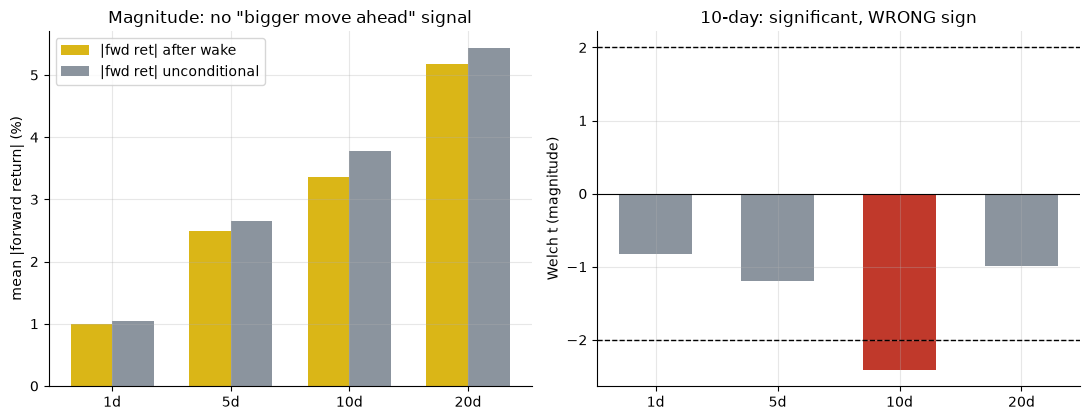

t_welch_abs by horizon: {1: -0.83, 5: -1.2, 10: -2.41, 20: -0.99}


In [3]:
if HAVE_REAL:
    a = list(res['mean_abs']*100); b = list(res['base_abs']*100)
    ta = list(res['t_welch_abs'])
else:
    a = [R['event'][h]['mean_abs'] for h in hs]
    b = [R['event'][h]['base_abs'] for h in hs]
    ta = [R['event'][h]['t_abs'] for h in hs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(x - w/2, a, width=w, color=AMBER, label='|fwd ret| after wake')
a1.bar(x + w/2, b, width=w, color=GREY, label='|fwd ret| unconditional')
a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('mean |forward return| (%)'); a1.legend()
a1.set_title('Magnitude: no "bigger move ahead" signal')
a2.bar(x, ta, color=[RED if abs(t)>=2 else GREY for t in ta], width=.6)
a2.axhline(2, ls='--', c='k', lw=1); a2.axhline(-2, ls='--', c='k', lw=1)
a2.axhline(0, c='k', lw=.8)
a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs])
a2.set_ylabel('Welch t (magnitude)'); a2.set_title('10-day: significant, WRONG sign')
plt.tight_layout(); plt.show()
print('t_welch_abs by horizon:', {h: round(t,2) for h,t in zip(hs, ta)})

> 💡 In plain words: at 10 days, moves after a wake are *smaller* than an ordinary day's (Welch *t* = -2.41) — the opposite of what "trend capture" predicts. It's one horizon out of four (not robust across the window, and the placebo assigns it no special standing — p = 0.977), but there is certainly no supporting evidence for H₂ anywhere.

### 4c · The third axis — a real timer, and the Sharpe trap it walks into

Enter the fan direction the bar after a wake, hold 10 sessions, one execution lag, 5 bps one-way costs, 50 bps/yr borrow on shorts, flat 4%/yr cash-leg proxy while flat (SPY, 2000→2026).

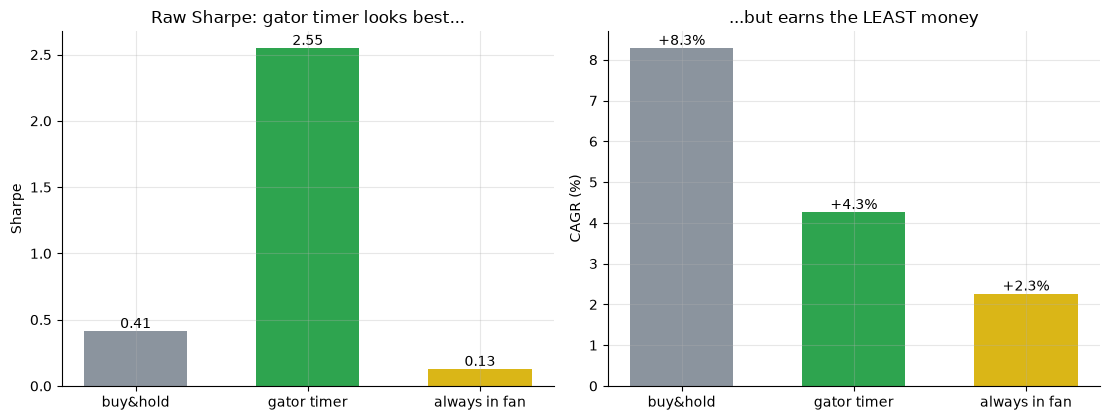

Sharpe-diff t (wake vs BH) = -1.16   (wake vs fan) = +0.65
block-permutation placebo p = 0.512  (observed diff +2.136)
n wakes on SPY = 13   in-position fraction = 0.90%


In [4]:
if HAVE_REAL:
    out = st.run_timer_experiment(SPY, placebo=True, n_draws=800)
    bh_s, wk_s, fan_s = out['bh']['sharpe'], out['wake']['sharpe'], out['fan']['sharpe']
    bh_c, wk_c, fan_c = out['bh']['cagr']*100, out['wake']['cagr']*100, out['fan']['cagr']*100
    twb, twf = out['t_wake_vs_bh'], out['t_wake_vs_fan']
    pval, pobs = out['placebo_p'], out['placebo_obs']
    n_w, ipf = out['n_wakes'], out['in_pos_frac']*100
else:
    bh_s, wk_s, fan_s = R['bh']['sharpe'], R['wake']['sharpe'], R['fan']['sharpe']
    bh_c, wk_c, fan_c = R['bh']['cagr'], R['wake']['cagr'], R['fan']['cagr']
    twb, twf = R['t_wake_vs_bh'], R['t_wake_vs_fan']
    pval, pobs = R['placebo_p'], R['placebo_obs']
    n_w, ipf = R['n_wakes_spy'], R['in_pos_frac']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar(['buy&hold','gator timer','always in fan'], [bh_s, wk_s, fan_s],
       color=[GREY, GREEN, AMBER], width=.6)
for i,v in enumerate([bh_s, wk_s, fan_s]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('Sharpe'); a1.set_title('Raw Sharpe: gator timer looks best...')
a2.bar(['buy&hold','gator timer','always in fan'], [bh_c, wk_c, fan_c],
       color=[GREY, GREEN, AMBER], width=.6)
for i,v in enumerate([bh_c, wk_c, fan_c]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('CAGR (%)'); a2.set_title('...but earns the LEAST money')
plt.tight_layout(); plt.show()
print(f'Sharpe-diff t (wake vs BH) = {twb:+.2f}   (wake vs fan) = {twf:+.2f}')
print(f'block-permutation placebo p = {pval:.3f}  (observed diff {pobs:+.3f})')
print(f'n wakes on SPY = {n_w}   in-position fraction = {ipf:.2f}%')

> 💡 In plain words: the wake timer's Sharpe (2.55) beats buy-and-hold's (0.41) only because it's a **90%**-cash strategy — 13 events in 26.5 years — with near-zero realized volatility from the flat cash leg. Its CAGR is *half* buy-and-hold's (+4.3% vs +8.3%). The honest tests both say "no edge": Sharpe-difference HAC *t* vs buy-and-hold = **-1.16** (not significant), and a block-permutation placebo shows a random reshuffle of the same sparse in/out pattern matches or beats the observed Sharpe gap **51%** of the time. Against the plain "always in the fan" rule (421's approach), the difference is **+0.65** — also not significant. H₃ fails on every honest test.

### 4d · Faithful-engine & power control — we know the truth here

A trend-persistence knob (`edge`), same family as sibling 421; each panel pools 20 independent synthetic series (the synthetic analogue of the real 30-name basket) so the wake-event detector has enough events to compute a meaningful *t*. The null (`edge=0`) is checked over **10 independent panel seeds** — never a single stream.

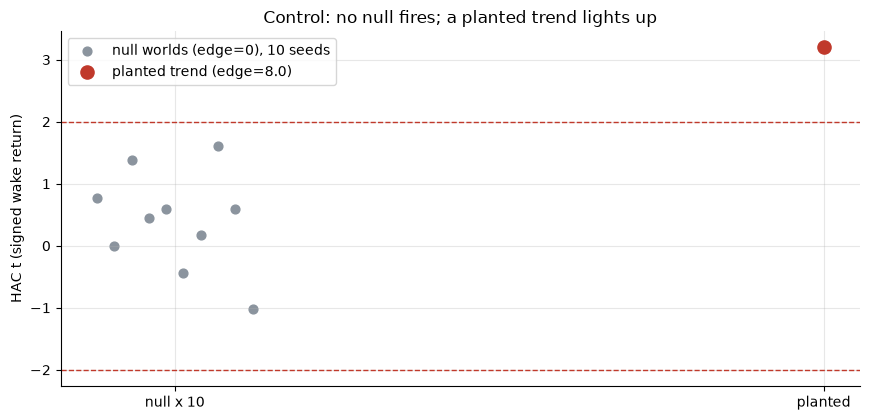

null: mean t = +0.41 (sd 0.78), |t|>=2 in 0/10 seeds  |  planted t = +3.20


In [5]:
null_ts = []
for s_ in range(10):
    pan = data.synthetic_multi_panel(edge=0.0, seed=676 + s_)
    null_ts.append(st.summarize(pan, horizon=st.HOLD_DAYS, placebo=False)['t_hac'])
null_ts = np.asarray(null_ts)
pan = data.synthetic_multi_panel(edge=8.0, seed=676)
sy = st.summarize(pan, horizon=st.HOLD_DAYS, placebo=False)
planted_t = sy['t_hac']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(10) + np.linspace(-.12,.12,10), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 10 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted trend (edge=8.0)')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 10', 'planted'])
ax.set_ylabel('HAC t (signed wake return)')
ax.set_title('Control: no null fires; a planted trend lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/10 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 10 null panels the detector averages t = +0.41 (sd 0.78) and **never** crosses the bar; a planted multi-week trend (`edge=8.0`) reads t = 3.20 (win rate 79%, n = 14). The machinery is unbiased and *can* catch a real trend — the flat real-tape result is a genuine "nothing there," not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — no horizon (1/5/10/20 days) of the signed post-wake return clears \|*t*\| ≥ 2 (HAC or Welch); the magnitude/trend-capture fallback shows the same at best, and the wrong sign at 10 days (Welch *t* = -2.41).
- **Tradability `MIRAGE`** — a real SPY timer's headline Sharpe (2.55) is a cash-dominance artifact (90% flat, 13 events in 26.5 years); the Sharpe-difference *t* vs buy-and-hold is -1.16 and vs the plain Alligator fan +0.65, neither significant, and a block-permutation placebo (p = 0.512) confirms it.
- **"Catches the start of a trend?" `BUSTED`** — the synthetic control proves the machinery *can* catch a planted trend (t = 3.20); on the real tape, watching the Gator's color change adds nothing over the Alligator fan it's built from.

## 6 · Going further

- **The general lesson: a derived transform carries no new information by construction.** The Gator is the rate-of-change of the Alligator's own spread — any edge it could have was already fully contained in the three lines it's built from. The honest prior, going in, should have been "at best equal to 421, likely worse after the extra filtering throws away most days as `not a wake'." The data agrees.
- **The Sharpe trap generalises.** Any strategy that's mostly in cash inflates its Sharpe ratio against a fully-invested benchmark purely through variance shrinkage — always test the *difference* with HAC inference and a permutation placebo, never read a raw Sharpe gap at face value.
- **Dedup map:** [421-williams-alligator](../../421-williams-alligator/) (the fan itself, run continuously — Weak/Mirage), [184-williams-fractals](../../184-williams-fractals/) (a different Williams pivot marker — None/Mirage), [420-awesome-oscillator](../../420-awesome-oscillator/) and [474-accelerator-oscillator](../../474-accelerator-oscillator/) (Williams' momentum cousins, unrelated construction — both None/Mirage). The whole Williams *Trading Chaos* toolkit reads the same way on this desk: intuitive stories, empty statistics.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*